In [31]:
import sys
print(sys.executable)

/usr/local/bin/python3


In [32]:
%pip install scikit-learn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Loading dataset...")
df = pd.read_csv(r"/Users/suhaas/Downloads/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df

Note: you may need to restart the kernel to use updated packages.
Loading dataset...


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [34]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [35]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [36]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


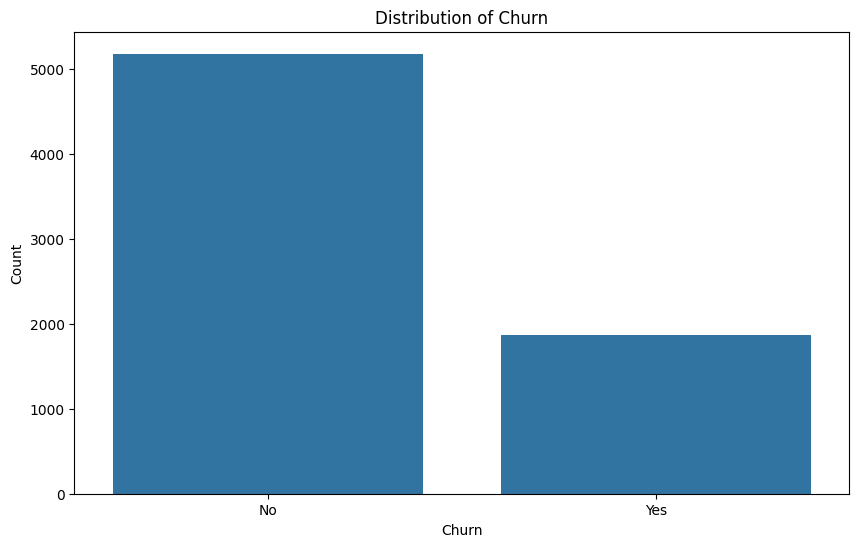

In [38]:
plt.figure(figsize=(10, 6))
sns.countplot(x="Churn", data=df)
plt.title("Distribution of Churn")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

In [39]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [ ]:
print("Churn Rate = {:.2f}%".format(df["Churn"].value_counts(normalize=True)["Yes"] * 100))


Churn Rate = 26.54%
Missing values will be filled after train test split to avoid data leakage.[filling missing values now will alter the test data also]
Dataset loaded successfully!


In [ ]:
y = df["Churn"].map({"Yes": 1, "No": 0})
X=df.drop("Churn", axis=1)

We change the target variable to binary for calculation of risk factor at the end to decide whether to retain the customer or not


In [42]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

In [43]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [44]:
from sklearn.preprocessing import OneHotEncoder

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [45]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

In [152]:
from sklearn.linear_model import LogisticRegression
model_log = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000, penalty="l2", solver="lbfgs", C=1.0
    ))
])

In [142]:
from sklearn.ensemble import RandomForestClassifier
model_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100, max_depth=10, random_state=42
    ))
])

In [ ]:
%pip install xgboost
%pip install --upgrade pip



Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [144]:
from xgboost import XGBClassifier
model_xgb = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42
    ))
])

In [147]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report
import numpy as np

In [148]:
skf = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

In [174]:
fold_results = []
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
#train and val idx return the index of rows in training and testing dataset respectively for each fold
#this is for logistic regression model
    print(f"\nFold: {fold}")

    X_train_fold = X.iloc[train_idx]
    y_train_fold = y.iloc[train_idx]

    X_val_fold = X.iloc[val_idx]
    y_val_fold = y.iloc[val_idx]

    model_log.fit(X_train_fold, y_train_fold)

    val_probs = model_log.predict_proba(X_val_fold)[:, 1]

    val_preds = (val_probs >= 0.54).astype(int)

    roc_auc = roc_auc_score(y_val_fold, val_probs)
    pr_auc = average_precision_score(y_val_fold, val_probs)

    report = classification_report(y_val_fold, val_preds, output_dict=True)

    recall = report["1"]["recall"]
    precision = report["1"]["precision"]

    fold_results.append({
        "fold": fold,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "recall": recall,
        "precision": precision
    })

    


Fold: 1

Fold: 2

Fold: 3


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarnin


Fold: 4

Fold: 5


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [175]:
log_results = pd.DataFrame(fold_results)

log_results

,fold,roc_auc,pr_auc,recall,precision
0,1,0.854523,0.658286,0.524064,0.675862
1,2,0.845491,0.658578,0.508021,0.688406
2,3,0.863293,0.700853,0.516043,0.712177
3,4,0.825130,0.619941,0.461126,0.651515
4,5,0.836214,0.644819,0.478610,0.670412


In [176]:
print("\nMean Metrics")
print(log_results.mean())

print("\nStd Deviation")
print(log_results.std())


Mean Metrics
fold         3.000000
roc_auc      0.844930
pr_auc       0.656495
recall       0.497573
precision    0.679674
dtype: float64

Std Deviation
fold         1.581139
roc_auc      0.014980
pr_auc       0.029359
recall       0.026646
precision    0.022505
dtype: float64


In [93]:
fold_results = []
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
#train and val idx return the index of rows in training and testing dataset respectively for each fold
#this is for random forests model
    print(f"\nFold: {fold}")

    X_train_fold = X.iloc[train_idx]
    y_train_fold = y.iloc[train_idx]

    X_val_fold = X.iloc[val_idx]
    y_val_fold = y.iloc[val_idx]

    model_rf.fit(X_train_fold, y_train_fold)

    val_probs = model_rf.predict_proba(X_val_fold)[:, 1]

    val_preds = (val_probs >= 0.4).astype(int)

    roc_auc = roc_auc_score(y_val_fold, val_probs)
    pr_auc = average_precision_score(y_val_fold, val_probs)

    report = classification_report(y_val_fold, val_preds, output_dict=True)

    recall = report["1"]["recall"]
    precision = report["1"]["precision"]

    fold_results.append({
        "fold": fold,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "recall": recall,
        "precision": precision
    })


Fold: 1

Fold: 2

Fold: 3

Fold: 4

Fold: 5


In [94]:
rf_results = pd.DataFrame(fold_results)

rf_results

,fold,roc_auc,pr_auc,recall,precision
0,1,0.842967,0.644830,0.473262,0.667925
1,2,0.836271,0.625185,0.508021,0.673759
2,3,0.836578,0.659752,0.433155,0.701299
3,4,0.804677,0.595342,0.383378,0.593361
4,5,0.831608,0.643298,0.459893,0.690763


In [95]:
print("\nMean Metrics")
print(rf_results.mean())

print("\nStd Deviation")
print(rf_results.std())


Mean Metrics
fold         3.000000
roc_auc      0.830420
pr_auc       0.633681
recall       0.451542
precision    0.665421
dtype: float64

Std Deviation
fold         1.581139
roc_auc      0.014947
pr_auc       0.024691
recall       0.046679
precision    0.042420
dtype: float64


In [ ]:
fold_results = []
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
#train and val idx return the index of rows in training and testing dataset respectively for each fold
#this is for xgboost model
    print(f"\nFold: {fold}")

    X_train_fold = X.iloc[train_idx]
    y_train_fold = y.iloc[train_idx]

    X_val_fold = X.iloc[val_idx]
    y_val_fold = y.iloc[val_idx]

    model_xgb.fit(X_train_fold, y_train_fold)

    val_probs = model_xgb.predict_proba(X_val_fold)[:, 1]

    val_preds = (val_probs >= 0.5).astype(int)

    roc_auc = roc_auc_score(y_val_fold, val_probs)
    pr_auc = average_precision_score(y_val_fold, val_probs)

    report = classification_report(y_val_fold, val_preds, output_dict=True)

    recall = report["1"]["recall"]
    precision = report["1"]["precision"]

    fold_results.append({
        "fold": fold,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "recall": recall,
        "precision": precision
    })


Fold: 1

Fold: 2

Fold: 3

Fold: 4

Fold: 5


In [97]:
xgb_results = pd.DataFrame(fold_results)

xgb_results

,fold,roc_auc,pr_auc,recall,precision
0,1,0.852860,0.670430,0.278075,0.781955
1,2,0.836234,0.644126,0.278075,0.759124
2,3,0.849423,0.677394,0.264706,0.804878
3,4,0.826909,0.617462,0.225201,0.717949
4,5,0.837885,0.646950,0.256684,0.780488


In [98]:
print("\nMean Metrics")
print(xgb_results.mean())

print("\nStd Deviation")
print(xgb_results.std())


Mean Metrics
fold         3.000000
roc_auc      0.840662
pr_auc       0.651272
recall       0.260548
precision    0.768879
dtype: float64

Std Deviation
fold         1.581139
roc_auc      0.010512
pr_auc       0.023782
recall       0.021772
precision    0.032752
dtype: float64


In [73]:
feature_names = model_log.named_steps["preprocessor"].get_feature_names_out()
coefs = model_log.named_steps["classifier"].coef_[0]

import pandas as pd

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefs
})

coef_df["abs_coef"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values(by="abs_coef", ascending=False)

coef_df.head(20)

,feature,coefficient,abs_coef
1,num__tenure,-1.062762,1.062762
5671,cat__Contract_Month-to-month,0.652400,0.652400
5673,cat__Contract_Two year,-0.578417,0.578417
5651,cat__InternetService_Fiber optic,0.339831,0.339831
5650,cat__InternetService_DSL,-0.279419,0.279419
3,num__TotalCharges,0.267409,0.267409
5678,cat__PaymentMethod_Electronic check,0.244920,0.244920
5662,cat__TechSupport_No,0.240892,0.240892
5653,cat__OnlineSecurity_No,0.236303,0.236303
5647,cat__MultipleLines_No,-0.207772,0.207772


In [172]:
results = X.copy()
results["churn_actual"] = y
churn_pred = model_log.predict(X)
results["churn_pred"] = churn_pred
results["churn_prob"] = model_log.predict_proba(X)[:, 1]
results["Expected Value"] = results["churn_prob"] * results["MonthlyCharges"] * 12
results.head(20)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,churn_actual,churn_pred,churn_prob,Expected Value
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,0,0.488121,174.844962
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,One year,No,Mailed check,56.95,1889.50,0,0,0.041102,28.089125
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,0,0.442554,285.978464
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,0,0.027561,13.989952
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,1,0.738682,626.697416
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1,1,0.831271,994.033749
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,0,1,0.504293,539.190383
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,Month-to-month,No,Mailed check,29.75,301.90,0,0,0.305963,109.228887
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1,1,0.668781,841.058422
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,One year,No,Bank transfer (automatic),56.15,3487.95,0,0,0.010452,7.042688


In [170]:
import numpy as np
thresholds = np.linspace(0.05, 0.8, 50)
profits = []
for threshold in thresholds:
    decision = (results["churn_prob"] >= threshold).astype(int)
    profit = ((decision) & (results["churn_actual"] == 1)) * (results["LTV"] - 500)
#if we retain a churning chustomer then the profit we saved is above and we add it to the profit
    profit -= ((decision) & (results["churn_actual"] == 0)) * 500
# if we retain a non churning customer then the cost we incur is above and we subtract it from the profit
    profit -= ((~decision) & (results["churn_actual"] == 1)) * results["LTV"]
# if we did not retain a churning customer then the loss we incur is above and we subtract it from the profit
#and someone who isnt churning we dont care about them
    profits.append(profit.sum())
best_threshold = thresholds[np.argmax(profits)]
print("Best Threshold: {:.2f}".format(best_threshold))

Best Threshold: 0.54


In [173]:
ranked_results = results.sort_values(by="Expected Value", ascending=False)
ranked_results["rank"] = np.arange(1, len(ranked_results) + 1)
ranked_results.head(20)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,churn_actual,churn_pred,churn_prob,Expected Value,rank
5933,6496-SLWHQ,Male,1,No,No,3,Yes,Yes,Fiber optic,No,...,Month-to-month,Yes,Electronic check,105.00,294.45,1,1,0.862526,1086.782815,1
6894,1400-MMYXY,Male,1,Yes,No,3,Yes,Yes,Fiber optic,No,...,Month-to-month,Yes,Electronic check,105.90,334.65,1,1,0.852524,1083.387846,2
4826,3389-YGYAI,Female,1,No,No,8,Yes,Yes,Fiber optic,No,...,Month-to-month,Yes,Electronic check,105.50,829.55,1,1,0.847414,1072.826154,3
261,3606-TWKGI,Male,1,No,No,13,Yes,Yes,Fiber optic,No,...,Month-to-month,Yes,Electronic check,106.90,1364.30,1,1,0.826728,1060.526537,4
2208,7216-EWTRS,Female,1,Yes,No,1,Yes,Yes,Fiber optic,No,...,Month-to-month,Yes,Electronic check,100.80,100.80,1,1,0.870923,1053.468932,5
2448,9221-OTIVJ,Female,1,No,No,14,Yes,Yes,Fiber optic,No,...,Month-to-month,Yes,Electronic check,104.85,1531.40,1,1,0.828914,1042.939746,6
6365,8884-ADFVN,Male,1,Yes,No,7,Yes,Yes,Fiber optic,No,...,Month-to-month,Yes,Electronic check,101.95,700.85,1,1,0.848588,1038.162562,7
6482,5419-JPRRN,Male,0,No,No,1,Yes,Yes,Fiber optic,No,...,Month-to-month,Yes,Electronic check,101.45,101.45,1,1,0.852180,1037.443400,8
1026,4822-RVYBB,Male,1,No,No,8,Yes,Yes,Fiber optic,No,...,Month-to-month,Yes,Electronic check,100.60,819.40,1,1,0.857294,1034.924990,9
905,0781-LKXBR,Male,1,No,No,9,Yes,Yes,Fiber optic,No,...,Month-to-month,Yes,Electronic check,100.50,918.60,1,1,0.854032,1029.962598,10
